# Assignment 3 — Fine-Tuning DistilBERT for Multi-Class Emotion Classification

**Title:** Fine-Tuning DistilBERT for Multi-Class Emotion Classification: A Comparative Study with TF-IDF Logistic Regression

**Research question:** To what extent does fine-tuning DistilBERT improve six-class emotion classification performance compared with a TF-IDF Logistic Regression baseline?

**Dataset:** Kaggle — `praveengovi/emotions-dataset-for-nlp`  
**Dataset files:** `train.txt`, `val.txt`, and `test.txt`  
**Primary model-selection metric:** Validation macro F1-score

This notebook implements the complete assignment workflow: public-dataset acquisition, data auditing, leakage-aware preprocessing, a tuned TF-IDF Logistic Regression baseline, DistilBERT tokenisation, a manual PyTorch fine-tuning loop, controlled hyperparameter comparison, final one-time test evaluation, required metrics, visualisations, error analysis, uncertainty analysis and reproducible artefact saving.



## Phase 1 — Environment and reproducibility

Core third-party packages are pinned to the versions used for the successful reference run. The GPU-compatible PyTorch build is supplied by the notebook runtime and its exact version is recorded in the run metadata rather than replaced by `pip`, which avoids breaking CUDA compatibility.


In [25]:
# Pin the assignment's tested library versions so results remain reproducible across notebook runtimes.
%pip install -q \
    "transformers==5.13.1" \
    "datasets==5.0.0" \
    "kagglehub==1.0.2" \
    "scikit-learn==1.6.1"


Note: you may need to restart the kernel to use updated packages.


In [26]:
# Configure writable cache locations before importing libraries that read these environment variables.
import os

# Select a predictable writable root for Colab, Kaggle, or local Jupyter.
# Prefer platform-specific working directories so caches and outputs remain writable in Colab and Kaggle.
if os.path.isdir("/content"):
    RUNTIME_ROOT = "/content"
elif os.path.isdir("/kaggle/working"):
    RUNTIME_ROOT = "/kaggle/working"
else:
    RUNTIME_ROOT = os.getcwd()

# Keep downloaded Kaggle data inside the selected runtime rather than relying on an unknown user cache.
os.environ["KAGGLEHUB_CACHE"] = os.path.join(RUNTIME_ROOT, "kagglehub_cache")

# Use a clean, writable Hugging Face cache and bypass the Xet CDN.
# This prevents transient signed-URL/403 errors on Colab and Kaggle.
# A dedicated Hugging Face cache avoids permission issues and makes model downloads easier to reproduce.
HF_HOME_DIR = os.path.join(RUNTIME_ROOT, "huggingface_cache")
os.environ["HF_HOME"] = HF_HOME_DIR
os.environ["HF_HUB_CACHE"] = os.path.join(HF_HOME_DIR, "hub")
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "180"

import gc
import hashlib
import json
import platform
import random
import shutil
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import transformers
import datasets
import huggingface_hub
from huggingface_hub import constants as hf_hub_constants

from datasets import ClassLabel, Dataset, DatasetDict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

# Suppress only FutureWarning messages so important runtime errors remain visible.
warnings.filterwarnings("ignore", category=FutureWarning)


# This helper is repeated before downloads because some environments import huggingface_hub before the flag is set.
def disable_hf_xet() -> None:
    """Disable Hugging Face Xet even when huggingface_hub was imported earlier."""
    os.environ["HF_HUB_DISABLE_XET"] = "1"
    hf_hub_constants.HF_HUB_DISABLE_XET = True


disable_hf_xet()

# Record the runtime and package environment used to generate the saved outputs.
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Hugging Face Hub:", huggingface_hub.__version__)
print("Xet disabled:", hf_hub_constants.HF_HUB_DISABLE_XET)
print("KaggleHub:", getattr(kagglehub, "__version__", "version unavailable"))
print("scikit-learn:", sklearn.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
Transformers: 5.13.1
Datasets: 5.0.0
Hugging Face Hub: 1.11.0
Xet disabled: True
KaggleHub: 1.0.2
scikit-learn: 1.6.1
CUDA available: True
GPU: Tesla T4


In [27]:
# Centralise all experimental choices so the same settings are reused consistently throughout the notebook.
@dataclass(frozen=True)
class Config:
    # Kaggle dataset and transformer model
    kaggle_dataset_handle: str = "praveengovi/emotions-dataset-for-nlp"
    model_name: str = "distilbert/distilbert-base-uncased"

    # Reproducibility
    seed: int = 42

    # Tokenisation and batching
    max_length: int = 128
    train_batch_size: int = 16
    eval_batch_size: int = 32
    num_workers: int = 0

    # Transformer fine-tuning
    # Two standard small learning rates are compared; changing only this factor supports a controlled experiment.
    learning_rates: tuple = (2e-5, 3e-5)
    epochs: int = 3
    weight_decay: float = 0.01
    # A brief warm-up reduces unstable updates at the start of fine-tuning before linear learning-rate decay.
    warmup_ratio: float = 0.10
    # Gradient clipping limits occasional large updates that can destabilise transformer fine-tuning.
    gradient_clip_norm: float = 1.0
    early_stopping_patience: int = 2
    minimum_improvement: float = 1e-4

    # Baseline model
    # Stratified folds preserve class proportions while selecting the baseline configuration from training data only.
    baseline_cv_folds: int = 3
    baseline_max_features: int = 40_000

    # Optional uncertainty analysis
    # One thousand paired resamples provide a practical uncertainty estimate without excessive notebook runtime.
    bootstrap_iterations: int = 1_000

    # Saved outputs
    output_dir: str = str(Path(RUNTIME_ROOT) / "emotion_assignment_outputs")


CFG = Config()
OUTPUT_DIR = Path(CFG.output_dir)
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Saving both PNG and PDF supports direct report insertion and scalable publication-quality output.
def save_and_show_figure(fig, file_stem: str) -> None:
    """Save a report-ready PNG and PDF, then display and close the figure."""
    png_path = FIGURE_DIR / f"{file_stem}.png"
    pdf_path = FIGURE_DIR / f"{file_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


print(json.dumps(asdict(CFG), indent=2, default=str))
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)


{
  "kaggle_dataset_handle": "praveengovi/emotions-dataset-for-nlp",
  "model_name": "distilbert/distilbert-base-uncased",
  "seed": 42,
  "max_length": 128,
  "train_batch_size": 16,
  "eval_batch_size": 32,
  "num_workers": 0,
  "learning_rates": [
    2e-05,
    3e-05
  ],
  "epochs": 3,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "gradient_clip_norm": 1.0,
  "early_stopping_patience": 2,
  "minimum_improvement": 0.0001,
  "baseline_cv_folds": 3,
  "baseline_max_features": 40000,
  "bootstrap_iterations": 1000,
  "output_dir": "/content/emotion_assignment_outputs"
}
Output directory: /content/emotion_assignment_outputs
Figure directory: /content/emotion_assignment_outputs/figures


In [28]:
# Fix random-number generators and select the fastest available device for reproducible training.
def seed_everything(seed: int) -> None:
    """Set the random seeds used by Python, NumPy and PyTorch."""
    # Seed Python hashing, Python's RNG, NumPy, and PyTorch so repeated runs use the same stochastic state.
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic kernels are preferred over maximum speed because fair hyperparameter comparison is the priority.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


seed_everything(CFG.seed)

# Prefer CUDA, then Apple MPS, and finally CPU without changing the modelling workflow.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Selected device:", DEVICE)
if DEVICE.type == "cpu":
    print("Use a Colab or Kaggle GPU runtime for the final full experiment.")


Selected device: cuda


## Phase 2 — Download, load and audit the Kaggle dataset

The public Kaggle dataset supplies official training, validation and test files. The parser uses only the final semicolon on each line as the separator, so semicolons inside a sentence do not break the label parsing.

The **test labels are never used for cleaning, tuning or checkpoint selection**. The official test partition is preserved after basic text validation and is evaluated only in the final evaluation phase.


In [29]:
# Acquire the official dataset splits, validate their structure, and record file fingerprints for reproducibility.
# Download the public Kaggle dataset.
# Authentication is normally not required for this unrestricted public dataset.
# Download through KaggleHub so the notebook is self-contained and does not depend on manually uploaded data.
try:
    kaggle_dataset_directory = Path(
        kagglehub.dataset_download(CFG.kaggle_dataset_handle)
    )
except Exception as exc:
    raise RuntimeError(
        "Kaggle could not download the public dataset. "
        "Check the Colab internet connection and rerun this cell. "
        "If Kaggle specifically requests authentication, create a Kaggle API "
        "token and add it to Colab Secrets as KAGGLE_API_TOKEN."
    ) from exc

print("Kaggle dataset directory:", kaggle_dataset_directory)

# Enumerate all files recursively because Kaggle archives can contain an extra nested directory.
all_downloaded_files = sorted(
    path
    for path in kaggle_dataset_directory.rglob("*")
    if path.is_file()
)

print("\nDownloaded files:")
for file_path in all_downloaded_files:
    print("-", file_path.relative_to(kaggle_dataset_directory))


# Resolve common validation-file naming variants while still requiring the official train/validation/test files.
def find_file_case_insensitive(possible_names: list[str]) -> Path:
    """Find one downloaded file using case-insensitive candidate names."""
    candidate_names = {name.lower() for name in possible_names}

    matches = [
        path
        for path in all_downloaded_files
        if path.name.lower() in candidate_names
    ]

    if not matches:
        raise FileNotFoundError(
            f"Could not find any of {sorted(candidate_names)} "
            f"inside {kaggle_dataset_directory}."
        )

    # Prefer the shortest relative path if duplicate copies exist.
    return sorted(
        matches,
        key=lambda path: len(path.relative_to(kaggle_dataset_directory).parts),
    )[0]


# Bind each semantic split name to one validated physical file before parsing.
dataset_files = {
    "train": find_file_case_insensitive(["train.txt"]),
    "validation": find_file_case_insensitive(
        ["val.txt", "validation.txt", "valid.txt"]
    ),
    "test": find_file_case_insensitive(["test.txt"]),
}

print("\nSelected split files:")
for split_name, file_path in dataset_files.items():
    print(f"{split_name:>10}: {file_path}")


# Fixed class order preserves the commonly used six-emotion label mapping.
# Use a fixed label order so integer IDs stay consistent across pandas, scikit-learn, and DistilBERT.
LABEL_NAMES = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise",
]
NUM_LABELS = len(LABEL_NAMES)
ID2LABEL = {index: name for index, name in enumerate(LABEL_NAMES)}
LABEL2ID = {name: index for index, name in enumerate(LABEL_NAMES)}


# Parse and validate every row explicitly instead of trusting malformed records to fail later during training.
def read_emotion_text_file(file_path: Path) -> pd.DataFrame:
    """
    Read a Kaggle split file formatted as:
        sentence;emotion

    rsplit is used so only the final semicolon separates text and label.
    """
    rows = []

    with file_path.open("r", encoding="utf-8", errors="replace") as file:
        for line_number, raw_line in enumerate(file, start=1):
            line = raw_line.strip()

            if not line:
                continue

            if ";" not in line:
                raise ValueError(
                    f"Missing ';' separator in {file_path.name}, "
                    f"line {line_number}."
                )

            # Split on the final semicolon so punctuation inside the sentence does not corrupt the label.
            text, emotion = line.rsplit(";", 1)
            text = text.strip()
            emotion = emotion.strip().lower()

            if not text:
                raise ValueError(
                    f"Empty text in {file_path.name}, line {line_number}."
                )

            if emotion not in LABEL2ID:
                raise ValueError(
                    f"Unexpected label '{emotion}' in {file_path.name}, "
                    f"line {line_number}. Expected one of {LABEL_NAMES}."
                )

            rows.append(
                {
                    "text": text,
                    "label": LABEL2ID[emotion],
                }
            )

    if not rows:
        raise ValueError(f"No valid records were read from {file_path}.")

    return pd.DataFrame(rows)


# Read the three official partitions.
# Keep the publisher's official partitions rather than creating a new random split.
kaggle_split_frames = {
    split_name: read_emotion_text_file(file_path)
    for split_name, file_path in dataset_files.items()
}

# Convert pandas frames into a Hugging Face DatasetDict so all later
# tokenisation and DataLoader code remains unchanged.
emotion_label_feature = ClassLabel(names=LABEL_NAMES)

# Cast labels to ClassLabel so names and integer IDs remain attached to the dataset object.
raw_dataset = DatasetDict(
    {
        split_name: Dataset.from_pandas(
            frame[["text", "label"]],
            preserve_index=False,
        ).cast_column("label", emotion_label_feature)
        for split_name, frame in kaggle_split_frames.items()
    }
)

# File hashes provide a reproducible fingerprint of the exact downloaded data.
# Hash each source file to document the exact dataset version used for the recorded outputs.
def sha256_file(file_path: Path) -> str:
    digest = hashlib.sha256()
    with file_path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


KAGGLE_FILE_HASHES = {
    split_name: sha256_file(file_path)
    for split_name, file_path in dataset_files.items()
}

print("\nDataset loaded successfully:")
print(raw_dataset)

for split_name, split_data in raw_dataset.items():
    print(f"{split_name:>10}: {len(split_data):,} records")

print("\nNumber of classes:", NUM_LABELS)
print("Label mapping:", ID2LABEL)
print("Dataset file SHA-256 hashes:", KAGGLE_FILE_HASHES)


Kaggle dataset directory: /kaggle/input/datasets/praveengovi/emotions-dataset-for-nlp

Downloaded files:
- test.txt
- train.txt
- val.txt

Selected split files:
     train: /kaggle/input/datasets/praveengovi/emotions-dataset-for-nlp/train.txt
validation: /kaggle/input/datasets/praveengovi/emotions-dataset-for-nlp/val.txt
      test: /kaggle/input/datasets/praveengovi/emotions-dataset-for-nlp/test.txt


Casting the dataset:   0%|          | 0/16000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]


Dataset loaded successfully:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
     train: 16,000 records
validation: 2,000 records
      test: 2,000 records

Number of classes: 6
Label mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Dataset file SHA-256 hashes: {'train': '3ab03d945a6cb783d818ccd06dafd52d2ed8b4f62f0f85a09d7d11870865b190', 'validation': '34faaa31962fe63cdf5dbf6c132ef8ab166c640254ab991af78f3aea375e79ef', 'test': '60f531690d20127339e7f054edc299a82c627b5ec0dd5d552d53d544e0cfcc17'}


In [30]:
# Convert the Hugging Face splits to pandas because the audit and cleaning steps use DataFrame operations.
# Copy only modelling columns to prevent hidden index columns from entering downstream operations.
split_frames = {
    split_name: split_data.to_pandas()[["text", "label"]].copy()
    for split_name, split_data in raw_dataset.items()
}
display(split_frames["train"].head())


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [31]:
# Quantify missing values, empty texts, duplicates, and conflicting labels before any cleaning is applied.
def audit_split(df: pd.DataFrame, split_name: str) -> dict:
    """Return important data-quality statistics for one partition."""
    # Normalise missing text to an empty string only for audit calculations; the original frame is not modified here.
    text_series = df["text"].fillna("").astype(str)
    # Count texts associated with more than one label because these examples provide contradictory supervision.
    conflict_count = (
        df.dropna(subset=["text", "label"])
        .groupby("text")["label"]
        .nunique()
        .gt(1)
        .sum()
    )
    return {
        "split": split_name,
        "rows": len(df),
        "missing_text": int(df["text"].isna().sum()),
        "missing_label": int(df["label"].isna().sum()),
        "empty_text": int(text_series.str.strip().eq("").sum()),
        "duplicate_rows_by_text": int(text_series.duplicated(keep=False).sum()),
        "conflicting_duplicate_texts": int(conflict_count),
    }


# Run the same audit function over every official partition for a directly comparable table.
initial_audit = pd.DataFrame(
    [audit_split(df, name) for name, df in split_frames.items()]
)
display(initial_audit)


,split,rows,missing_text,missing_label,empty_text,duplicate_rows_by_text,conflicting_duplicate_texts
0,train,16000,0,0,0,62,30
1,validation,2000,0,0,0,4,2
2,test,2000,0,0,0,0,0


In [32]:
# Audit exact text overlap between the official splits before model development.
def normalised_text_set(df: pd.DataFrame) -> set[str]:
    """Create a whitespace-normalised set for an exact-overlap audit."""
    # Whitespace normalisation catches exact-content duplicates that differ only in spacing.
    return set(
        df["text"]
        .dropna()
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


train_texts_raw = normalised_text_set(split_frames["train"])
validation_texts_raw = normalised_text_set(split_frames["validation"])
test_texts_raw = normalised_text_set(split_frames["test"])

# Use text content only for overlap detection; labels from the protected test set are never consulted.
overlap_audit = pd.DataFrame(
    {
        "split_pair": ["train-validation", "train-test", "validation-test"],
        "exact_text_overlap": [
            len(train_texts_raw & validation_texts_raw),
            len(train_texts_raw & test_texts_raw),
            len(validation_texts_raw & test_texts_raw),
        ],
    }
)
display(overlap_audit)


,split_pair,exact_text_overlap
0,train-validation,5
1,train-test,11
2,validation-test,3


### Cleaning and leakage prevention

The cleaning policy is deliberately asymmetric:

- Missing or empty records are checked independently in every split.
- Conflicting-label texts and duplicate texts are removed **from training only**, using training labels only.
- The official test set is preserved and its labels are not consulted.
- Exact text overlap is removed from validation when it appears in test, and from training when it appears in either evaluation partition.

This protects the holdout test set while preventing identical text from entering model fitting or validation-based checkpoint selection.


In [33]:
# Clean and protect the splits before EDA or training so later analysis cannot learn from duplicated holdout content.
def normalise_and_validate_split(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Normalise whitespace and remove records with missing/empty fields."""
    # Work on a copy so the untouched official frames remain available for reconciliation checks.
    working = df.copy()
    normalised_text = (
        working["text"]
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # Remove only records that cannot be modelled: missing text, missing labels, or empty normalised text.
    invalid_mask = (
        working["text"].isna()
        | working["label"].isna()
        | normalised_text.eq("")
    )
    invalid_count = int(invalid_mask.sum())

    cleaned = working.loc[~invalid_mask].copy()
    cleaned["text"] = normalised_text.loc[~invalid_mask]
    cleaned["label"] = cleaned["label"].astype(int)
    return cleaned.reset_index(drop=True), invalid_count


def clean_and_protect_splits(frames: dict[str, pd.DataFrame]) -> tuple:
    """
    Clean the dataset without using test labels for any decision.

    The test partition is retained after independent validity checks. Training
    conflicts are identified from training labels only. Cross-split protection
    uses text strings, never test labels.
    """
    normalised = {}
    invalid_removed = {}

    # Basic validity checks are applied independently before any cross-split comparison.
    for split_name, frame in frames.items():
        normalised[split_name], invalid_removed[split_name] = (
            normalise_and_validate_split(frame)
        )

    # Cleaning starts before EDA and training so duplicated or contradictory examples cannot bias plots, tuning, or fitting.
    # 1. Detect label conflicts inside training only.
    train_initial = normalised["train"]
    # Test and validation labels are deliberately excluded from conflict detection to protect the holdout protocol.
    training_conflict_counts = train_initial.groupby("text")["label"].nunique()
    training_conflicting_texts = set(
        training_conflict_counts[training_conflict_counts > 1].index
    )
    train_without_conflicts = train_initial.loc[
        ~train_initial["text"].isin(training_conflicting_texts)
    ].copy()
    training_conflict_rows_removed = len(train_initial) - len(train_without_conflicts)

    # 2. Remove repeated training texts after conflict removal.
    # Keep one copy of repeated training text to avoid overweighting duplicated examples.
    train_deduplicated = train_without_conflicts.drop_duplicates(
        subset="text",
        keep="first",
    ).copy()
    training_duplicate_rows_removed = (
        len(train_without_conflicts) - len(train_deduplicated)
    )

    # 3. Preserve the official test partition. Remove validation texts that
    #    also occur in test so test content cannot influence model selection.
    # Preserve all independently valid official test rows; the test set is not edited based on model-development needs.
    test_final = normalised["test"].copy()
    test_texts = set(test_final["text"])

    validation_initial = normalised["validation"]
    # Remove validation text found in test so checkpoint selection cannot indirectly see test content.
    validation_final = validation_initial.loc[
        ~validation_initial["text"].isin(test_texts)
    ].copy()
    validation_overlap_rows_removed = len(validation_initial) - len(validation_final)

    # 4. Remove any training text occurring in either evaluation partition.
    # Remove from training any text present in either evaluation split to prevent exact-text memorisation leakage.
    protected_evaluation_texts = set(validation_final["text"]) | test_texts
    train_final = train_deduplicated.loc[
        ~train_deduplicated["text"].isin(protected_evaluation_texts)
    ].copy()
    training_overlap_rows_removed = len(train_deduplicated) - len(train_final)

    result = {
        "train": train_final.reset_index(drop=True),
        "validation": validation_final.reset_index(drop=True),
        "test": test_final.reset_index(drop=True),
    }

    # Reconcile every removal category so the cleaning procedure is transparent and auditable.
    summary = pd.DataFrame(
        [
            {
                "split": "train",
                "original_rows": len(frames["train"]),
                "invalid_or_empty_removed": invalid_removed["train"],
                "label_conflict_rows_removed": training_conflict_rows_removed,
                "within_split_duplicate_rows_removed": training_duplicate_rows_removed,
                "cross_split_overlap_rows_removed": training_overlap_rows_removed,
                "final_rows": len(result["train"]),
            },
            {
                "split": "validation",
                "original_rows": len(frames["validation"]),
                "invalid_or_empty_removed": invalid_removed["validation"],
                "label_conflict_rows_removed": 0,
                "within_split_duplicate_rows_removed": 0,
                "cross_split_overlap_rows_removed": validation_overlap_rows_removed,
                "final_rows": len(result["validation"]),
            },
            {
                "split": "test",
                "original_rows": len(frames["test"]),
                "invalid_or_empty_removed": invalid_removed["test"],
                "label_conflict_rows_removed": 0,
                "within_split_duplicate_rows_removed": 0,
                "cross_split_overlap_rows_removed": 0,
                "final_rows": len(result["test"]),
            },
        ]
    )

    removal_columns = [
        "invalid_or_empty_removed",
        "label_conflict_rows_removed",
        "within_split_duplicate_rows_removed",
        "cross_split_overlap_rows_removed",
    ]
    summary["rows_removed_total"] = summary[removal_columns].sum(axis=1)
    # A true reconciliation flag confirms original rows minus documented removals equals final rows.
    summary["reconciles"] = (
        summary["original_rows"]
        - summary["rows_removed_total"]
        == summary["final_rows"]
    )

    return result, summary, training_conflicting_texts


# Expose protected DataFrames only after the complete cleaning policy has finished.
cleaned_frames, cleaning_summary, training_conflicting_texts = (
    clean_and_protect_splits(split_frames)
)
train_df = cleaned_frames["train"]
validation_df = cleaned_frames["validation"]
test_df = cleaned_frames["test"]

display(cleaning_summary)
print("Training-only conflicting texts removed:", len(training_conflicting_texts))
print("Official test rows retained:", len(test_df), "of", len(split_frames["test"]))


,split,original_rows,invalid_or_empty_removed,label_conflict_rows_removed,within_split_duplicate_rows_removed,cross_split_overlap_rows_removed,final_rows,rows_removed_total,reconciles
0,train,16000,0,60,1,16,15923,77,True
1,validation,2000,0,0,0,3,1997,3,True
2,test,2000,0,0,0,0,2000,0,True


Training-only conflicting texts removed: 30
Official test rows retained: 2000 of 2000


In [34]:
# Fail immediately if cleaning did not remove leakage or created invalid split contents.
# Assertions turn the intended experimental protocol into executable safeguards rather than relying on inspection.
# Cross-partition exact-text leakage must be absent after cleaning.
assert not set(train_df["text"]) & set(validation_df["text"])
assert not set(train_df["text"]) & set(test_df["text"])
assert not set(validation_df["text"]) & set(test_df["text"])

# Training must contain one unambiguous label per unique text.
assert not train_df["text"].duplicated().any()
assert train_df.groupby("text")["label"].nunique().max() == 1

# All partitions must contain valid text and known integer labels.
for split_name, frame in cleaned_frames.items():
    assert frame["text"].notna().all(), f"Missing text in {split_name}."
    assert frame["text"].str.strip().ne("").all(), f"Empty text in {split_name}."
    assert frame["label"].between(0, NUM_LABELS - 1).all(), (
        f"Unexpected label in {split_name}."
    )

# Verify that test rows changed only for independently invalid or empty records, never because of labels or overlaps.
# The test set is preserved except for independently invalid/empty records.
expected_test_rows = (
    len(split_frames["test"])
    - int(
        cleaning_summary.loc[
            cleaning_summary["split"].eq("test"),
            "invalid_or_empty_removed",
        ].iloc[0]
    )
)
assert len(test_df) == expected_test_rows
assert cleaning_summary["reconciles"].all()

print("All data-quality, reconciliation and leakage assertions passed.")


All data-quality, reconciliation and leakage assertions passed.


## Phase 3 — Exploratory data analysis

Class balance and text length are examined because they influence the choice of macro-averaged metrics and the maximum token sequence length.


In [35]:
# Summarise post-cleaning split sizes and text lengths for the report.
def make_split_summary(frames: dict) -> pd.DataFrame:
    rows = []
    for split_name, frame in frames.items():
        # Word counts are sufficient for descriptive EDA; token-level lengths are checked later with the actual tokenizer.
        lengths = frame["text"].str.split().str.len()
        rows.append(
            {
                "split": split_name,
                "records": len(frame),
                "mean_words": lengths.mean(),
                "median_words": lengths.median(),
                "maximum_words": lengths.max(),
            }
        )
    return pd.DataFrame(rows)


split_summary = make_split_summary(cleaned_frames)
display(split_summary.round(2))


,split,records,mean_words,median_words,maximum_words
0,train,15923,19.18,17.0,66
1,validation,1997,18.85,17.0,61
2,test,2000,19.15,17.0,61


In [36]:
# Calculate class counts and proportions separately for every protected split.
class_distribution_parts = []

for split_name, frame in cleaned_frames.items():
    # Reindex all label IDs so even an absent class would still appear with count zero.
    counts = (
        frame["label"]
        .value_counts()
        .reindex(range(NUM_LABELS), fill_value=0)
        .rename_axis("label")
        .reset_index(name="count")
    )
    counts["class_name"] = counts["label"].map(ID2LABEL)
    # Proportions allow class balance to be compared across splits of different sizes.
    counts["proportion"] = counts["count"] / counts["count"].sum()
    counts["split"] = split_name
    class_distribution_parts.append(counts)

class_distribution = pd.concat(class_distribution_parts, ignore_index=True)
display(class_distribution)


,label,count,class_name,proportion,split
0,0,4661,sadness,0.292721,train
1,1,5340,joy,0.335364,train
2,2,1283,love,0.080575,train
3,3,2152,anger,0.135150,train
4,4,1923,fear,0.120769,train
5,5,564,surprise,0.035420,train
6,0,550,sadness,0.275413,validation
7,1,703,joy,0.352028,validation
8,2,177,love,0.088633,validation
9,3,275,anger,0.137707,validation


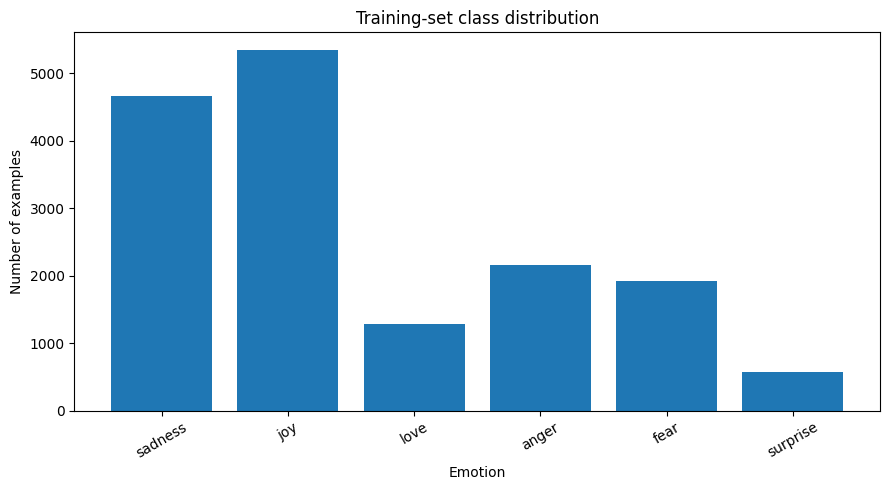

In [37]:
# Visualise training-class imbalance because it motivates class balancing and macro-averaged evaluation.
# Plot training counts only because this is the distribution that directly affects model fitting.
training_counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(NUM_LABELS), fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    [ID2LABEL[index] for index in training_counts.index],
    training_counts.values,
)
ax.set_title("Training-set class distribution")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of examples")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_and_show_figure(fig, "training_class_distribution")


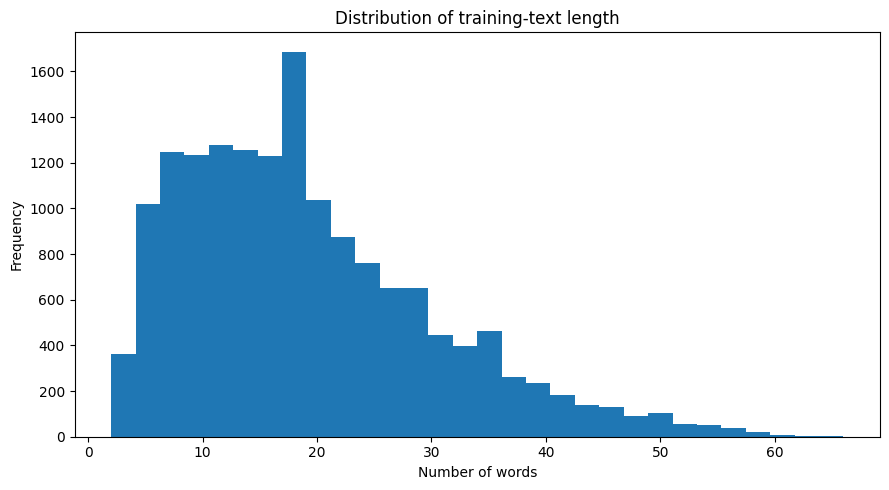

,word_count
0.50,17.0
0.75,25.0
0.90,35.0
0.95,41.0
0.99,52.0


In [38]:
# Inspect training text lengths to justify the transformer's maximum sequence length.
# Use only training text to avoid drawing preprocessing choices from validation or test examples.
train_word_lengths = train_df["text"].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(train_word_lengths, bins=30)
ax.set_title("Distribution of training-text length")
ax.set_xlabel("Number of words")
ax.set_ylabel("Frequency")
fig.tight_layout()
save_and_show_figure(fig, "training_text_length_distribution")

# Quantiles reveal typical and extreme sequence lengths more clearly than the histogram alone.
display(
    train_word_lengths.quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    .rename("word_count")
    .to_frame()
)


## Phase 4 — Reusable evaluation functions

The assignment requires accuracy, precision, recall and F1-score. Macro averages are emphasised because every emotion should contribute equally despite class imbalance.


In [39]:
# Define reusable evaluation helpers so both models are assessed with exactly the same metrics.
def calculate_metrics(y_true, y_pred) -> dict:
    """Calculate the required classification metrics."""
    # Macro precision, recall, and F1 give every emotion equal influence despite unequal class frequencies.
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        # Weighted F1 is retained as a complementary frequency-sensitive metric, not the selection criterion.
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }


def make_classification_report(y_true, y_pred) -> pd.DataFrame:
    """Return class-level precision, recall, F1 and support."""
    # Fix the full label order so minority classes remain visible even if a model predicts none of them.
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_LABELS)),
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose()


def plot_confusion(
    y_true,
    y_pred,
    title: str,
    file_stem: str,
    normalize=None,
) -> None:
    """Plot and save a labelled confusion matrix."""
    # Optional row normalisation converts counts into per-true-class error rates.
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_LABELS)),
        normalize=normalize,
    )
    fig, ax = plt.subplots(figsize=(8, 7))
    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=LABEL_NAMES,
    )
    display_object.plot(
        ax=ax,
        # Show decimals for normalised matrices and integer counts for raw matrices.
        values_format=".2f" if normalize else "d",
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    save_and_show_figure(fig, file_stem)


## Phase 5 — Baseline selection: TF-IDF + Logistic Regression

The baseline uses unigram and bigram TF-IDF features. Three-fold stratified cross-validation on the **training split only** selects regularisation strength and class weighting. Validation performance is reported after selection, but the test set remains untouched until the final evaluation phase.


In [40]:
# Tune the classical baseline only on the training split using stratified cross-validation.
baseline_pipeline = Pipeline(
    [
        (
            "tfidf",
            # Unigrams capture individual emotion words while bigrams capture short contextual phrases and negation.
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                # Ignore one-off terms that add dimensionality but provide little reusable evidence.
                min_df=2,
                max_features=CFG.baseline_max_features,
                # Log-scaled term frequency reduces domination by words repeated many times in one document.
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            # Logistic Regression is a strong interpretable linear baseline for sparse TF-IDF features.
            LogisticRegression(
                max_iter=2_000,
                random_state=CFG.seed,
            ),
        ),
    ]
)

baseline_parameter_grid = {
    "classifier__C": [0.5, 1.0, 2.0],
    # "balanced" is tested because minority emotions such as love and surprise otherwise contribute less to the loss.
    "classifier__class_weight": [None, "balanced"],
}

# Stratification keeps all six emotion proportions approximately stable in every fold.
baseline_cv = StratifiedKFold(
    n_splits=CFG.baseline_cv_folds,
    shuffle=True,
    random_state=CFG.seed,
)

baseline_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=baseline_parameter_grid,
    # Macro F1 is the selection metric because each emotion must count equally despite class imbalance.
    scoring="f1_macro",
    cv=baseline_cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=True,
)

baseline_start = time.perf_counter()
# Fit and tune on training data only; validation and test data do not influence this search.
baseline_search.fit(train_df["text"], train_df["label"])
baseline_training_seconds = time.perf_counter() - baseline_start

print("Best parameters:", baseline_search.best_params_)
print("Best cross-validation macro F1:", round(baseline_search.best_score_, 4))
print("Tuning time (seconds):", round(baseline_training_seconds, 2))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'classifier__C': 2.0, 'classifier__class_weight': 'balanced'}
Best cross-validation macro F1: 0.8368
Tuning time (seconds): 30.4


In [41]:
# Present all baseline cross-validation candidates rather than reporting only the winning setting.
# Retain train and validation-fold scores to inspect both ranking stability and possible overfitting.
baseline_cv_results = pd.DataFrame(baseline_search.cv_results_)
baseline_cv_columns = [
    "param_classifier__C",
    "param_classifier__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_fit_time",
]
display(
    baseline_cv_results[baseline_cv_columns]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
    .round(4)
)


,param_classifier__C,param_classifier__class_weight,mean_train_score,mean_test_score,std_test_score,rank_test_score,mean_fit_time
0,2.0,balanced,0.9790,0.8368,0.0071,1,2.9432
1,1.0,balanced,0.9609,0.8249,0.0083,2,3.6330
2,0.5,balanced,0.9339,0.8058,0.0042,3,2.8187
3,2.0,None,0.9789,0.7451,0.0035,4,4.6592
4,1.0,None,0.8876,0.6658,0.0037,5,3.6889
5,0.5,None,0.6705,0.5143,0.0052,6,3.4177


In [42]:
# Evaluate the already-selected baseline on validation data while keeping the test split untouched.
# Freeze the baseline chosen by training-only cross-validation before inspecting validation performance.
best_baseline = baseline_search.best_estimator_

# Validation results support comparison and reporting but do not reopen the already-completed baseline search.
baseline_validation_predictions = best_baseline.predict(
    validation_df["text"]
)
baseline_validation_metrics = calculate_metrics(
    validation_df["label"].to_numpy(),
    baseline_validation_predictions,
)

display(
    pd.DataFrame(
        [baseline_validation_metrics],
        index=["TF-IDF Logistic Regression — validation"],
    ).round(4)
)

print(
    "The baseline configuration is now fixed. "
    "No test prediction has been generated."
)


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
TF-IDF Logistic Regression — validation,0.8888,0.8492,0.8762,0.8612,0.8896


The baseline configuration is now fixed. No test prediction has been generated.


## Phase 6 — DistilBERT tokenizer and DataLoaders

The tokenizer paired with the selected pretrained model is used. Dynamic padding pads each batch only to its longest sequence. A new, identically seeded training DataLoader is created inside every learning-rate experiment so the compared runs receive the same deterministic shuffle sequence.


In [43]:
# Load the matching tokenizer and estimate how often the configured token limit will truncate inputs.
def load_tokenizer():
    """Load the tokenizer through the standard Hub download path."""
    disable_hf_xet()
    # Attempt the cached standard download first to avoid unnecessary network traffic.
    try:
        return AutoTokenizer.from_pretrained(
            CFG.model_name,
            cache_dir=os.environ["HF_HUB_CACHE"],
            token=False,
        )
    # Retry only recognised transient download failures; unrelated errors are raised unchanged for diagnosis.
    except OSError as error:
        message = str(error).lower()
        if not any(term in message for term in ("403", "xet", "signature", "connection")):
            raise

        print("Tokenizer download failed once; retrying with a fresh standard HTTP request.")
        disable_hf_xet()
        return AutoTokenizer.from_pretrained(
            CFG.model_name,
            cache_dir=os.environ["HF_HUB_CACHE"],
            token=False,
            force_download=True,
        )


tokenizer = load_tokenizer()


def token_length(text: str) -> int:
    return len(
        tokenizer.encode(
            text,
            add_special_tokens=False,
            truncation=False,
        )
    )


# Sample up to 5,000 training texts to justify max_length without spending time tokenising the full corpus twice.
token_length_sample = train_df["text"].sample(
    n=min(5_000, len(train_df)),
    random_state=CFG.seed,
)
# Use the exact DistilBERT tokenizer because word counts and subword-token counts are not equivalent.
sample_token_lengths = token_length_sample.map(token_length)

display(
    sample_token_lengths
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
    .rename("token_count")
    .to_frame()
)
print("Maximum sequence length:", CFG.max_length)
print(
    # Report the expected information loss associated with the fixed sequence limit.
    "Estimated sample requiring truncation:",
    round((sample_token_lengths > CFG.max_length).mean() * 100, 2),
    "%",
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,token_count
0.50,18.0
0.75,27.0
0.90,37.0
0.95,43.0
0.99,55.0
1.00,85.0


Maximum sequence length: 128
Estimated sample requiring truncation: 0.0 %


In [44]:
# Tokenise each protected split once and use dynamic padding later at batch time.
def frame_to_hf_dataset(frame: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(
        # Retain only inputs and targets and reset indices so no pandas metadata becomes a model feature.
        frame[["text", "label"]].reset_index(drop=True),
        preserve_index=False,
    )


hf_cleaned = DatasetDict(
    {
        split_name: frame_to_hf_dataset(frame)
        for split_name, frame in cleaned_frames.items()
    }
)


# Truncate to the justified limit but defer padding so each batch is padded only to its longest sequence.
def tokenize_batch(batch: dict) -> dict:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=CFG.max_length,
        return_token_type_ids=False,
    )


# Batched mapping is substantially faster than tokenising one example at a time.
tokenized_dataset = hf_cleaned.map(
    tokenize_batch,
    batched=True,
    # Remove raw text after tokenisation because the PyTorch model accepts tensor fields, not strings.
    remove_columns=["text"],
    desc="Tokenising dataset",
)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

# Dynamic padding reduces wasted computation compared with padding every example to max_length.
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt",
)

print(tokenized_dataset)


Tokenising dataset:   0%|          | 0/15923 [00:00<?, ? examples/s]

Tokenising dataset:   0%|          | 0/1997 [00:00<?, ? examples/s]

Tokenising dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 15923
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1997
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [45]:
# Build deterministic loaders so learning-rate experiments receive comparable batch orders.
def make_train_loader(seed: int) -> DataLoader:
    """Create a fresh, deterministically shuffled loader for one experiment."""
    generator = torch.Generator()
    # A seeded generator makes shuffle order reproducible and identical across learning-rate experiments.
    generator.manual_seed(seed)
    return DataLoader(
        tokenized_dataset["train"],
        batch_size=CFG.train_batch_size,
        # Shuffle only training data to reduce order effects during optimisation.
        shuffle=True,
        generator=generator,
        collate_fn=data_collator,
        num_workers=CFG.num_workers,
        # Pinned memory can speed host-to-GPU transfer but is enabled only when CUDA is actually used.
        pin_memory=DEVICE.type == "cuda",
    )


# Evaluation loaders are not shuffled so predictions align with the original row order.
validation_loader = DataLoader(
    tokenized_dataset["validation"],
    batch_size=CFG.eval_batch_size,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=CFG.num_workers,
    pin_memory=DEVICE.type == "cuda",
)

test_loader = DataLoader(
    tokenized_dataset["test"],
    batch_size=CFG.eval_batch_size,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=CFG.num_workers,
    pin_memory=DEVICE.type == "cuda",
)

# Inspect one batch shape as a lightweight pipeline check, then delete it to avoid retaining extra memory.
preview_loader = make_train_loader(CFG.seed)
first_batch = next(iter(preview_loader))
print({key: tuple(value.shape) for key, value in first_batch.items()})
del preview_loader, first_batch


{'labels': (16,), 'input_ids': (16, 47), 'attention_mask': (16, 47)}


## Phase 7 — Architecture and pipeline

**Raw text → DistilBERT tokenizer → token IDs and attention mask → pretrained DistilBERT encoder → dropout and linear classification head → six-class logits → softmax probabilities and predicted label**

All encoder layers and the newly initialised classification head are fine-tuned jointly.


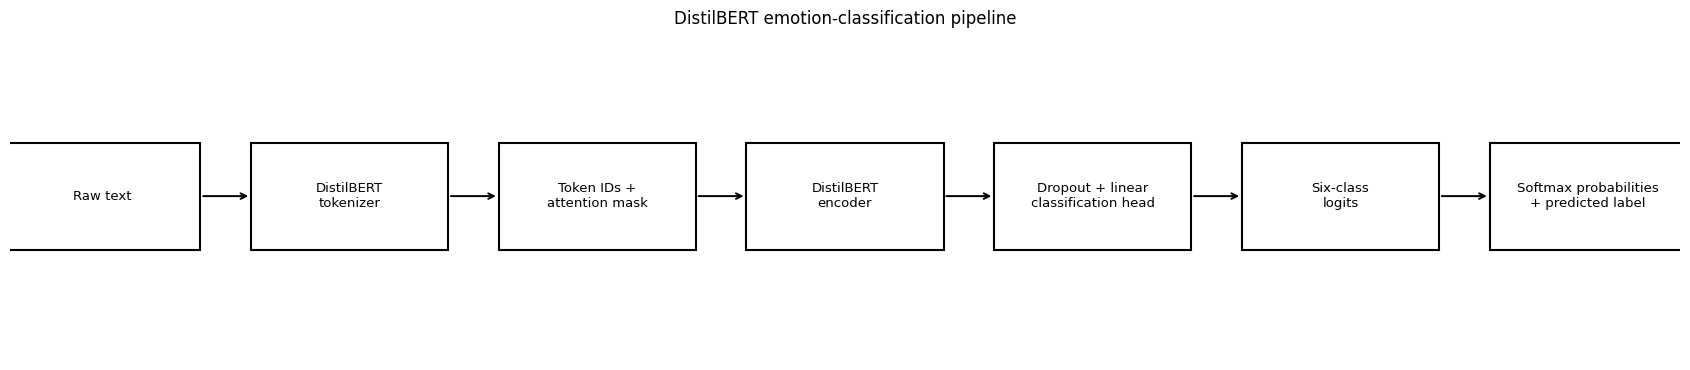

In [46]:
# Draw the end-to-end model pipeline as a report-ready architecture figure.
# List each transformation from raw text to predicted label in the order used by the implementation.
pipeline_steps = [
    "Raw text",
    "DistilBERT\ntokenizer",
    "Token IDs +\nattention mask",
    "DistilBERT\nencoder",
    "Dropout + linear\nclassification head",
    "Six-class\nlogits",
    "Softmax probabilities\n+ predicted label",
]

fig, ax = plt.subplots(figsize=(17, 3.8))
ax.axis("off")
x_positions = np.linspace(0.055, 0.945, len(pipeline_steps))
box_width = 0.118
box_height = 0.34

# Draw equal-width stages and arrows programmatically so the architecture figure remains consistent.
for index, (x_position, label) in enumerate(zip(x_positions, pipeline_steps)):
    rectangle = plt.Rectangle(
        (x_position - box_width / 2, 0.35),
        box_width,
        box_height,
        fill=False,
        linewidth=1.5,
    )
    ax.add_patch(rectangle)
    ax.text(x_position, 0.52, label, ha="center", va="center", fontsize=9.5)

    if index < len(pipeline_steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[index + 1] - box_width / 2, 0.52),
            xytext=(x_position + box_width / 2, 0.52),
            arrowprops={"arrowstyle": "->", "linewidth": 1.4},
        )

ax.set_title("DistilBERT emotion-classification pipeline", pad=15)
fig.tight_layout()
save_and_show_figure(fig, "distilbert_architecture_pipeline")


In [47]:
# Initialise a fresh pretrained classifier for each controlled experiment and summarise its trainable capacity.
def build_model():
    """Initialise a fresh pretrained DistilBERT sequence classifier.

    The fallback bypasses Hugging Face Xet and requests the PyTorch checkpoint
    if the safetensors CDN returns a transient 403/signature error.
    """
    disable_hf_xet()

    # Supply explicit label mappings so saved checkpoints produce human-readable emotion names.
    common_arguments = {
        "pretrained_model_name_or_path": CFG.model_name,
        "num_labels": NUM_LABELS,
        "id2label": ID2LABEL,
        "label2id": LABEL2ID,
        "cache_dir": os.environ["HF_HUB_CACHE"],
        "token": False,
    }

    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            **common_arguments,
            # Prefer safetensors for safe and efficient loading when the primary download path is available.
            use_safetensors=True,
        )
    except OSError as error:
        message = str(error).lower()
        # Fall back only for recognised transient CDN/Xet failures rather than masking genuine configuration errors.
        recoverable_terms = ("403", "xet", "signature", "invalid key pair", "connection")
        if not any(term in message for term in recoverable_terms):
            raise

        print(
            "The safetensors download was blocked by a transient Hugging Face "
            "CDN/Xet error. Retrying through standard HTTP with pytorch_model.bin."
        )
        disable_hf_xet()
        model = AutoModelForSequenceClassification.from_pretrained(
            **common_arguments,
            use_safetensors=False,
            force_download=True,
        )

    # Move the complete encoder and classification head to the selected device for joint fine-tuning.
    return model.to(DEVICE)


architecture_model = build_model()
total_parameters = sum(parameter.numel() for parameter in architecture_model.parameters())
# Count parameters with requires_grad=True to confirm all encoder layers and the new head are trainable.
trainable_parameters = sum(
    parameter.numel()
    for parameter in architecture_model.parameters()
    if parameter.requires_grad
)

print(architecture_model)
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

architecture_summary = pd.DataFrame(
    [
        {
            "pretrained_model": CFG.model_name,
            "transformer_layers": 6,
            "hidden_size": 768,
            "attention_heads": 12,
            "maximum_input_tokens": CFG.max_length,
            "number_of_classes": NUM_LABELS,
            "total_parameters": total_parameters,
            "trainable_parameters": trainable_parameters,
        }
    ]
)
display(architecture_summary)

# Release this inspection-only model before experiments to avoid unnecessary CPU/GPU memory pressure.
del architecture_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


,pretrained_model,transformer_layers,hidden_size,attention_heads,maximum_input_tokens,number_of_classes,total_parameters,trainable_parameters
0,distilbert/distilbert-base-uncased,6,768,12,128,6,66958086,66958086


## Phase 8 — Manual PyTorch training loop

The implementation explicitly performs forward propagation, cross-entropy loss calculation, backpropagation, gradient clipping, AdamW optimisation, linear warm-up and decay, validation after every epoch, early stopping and best-checkpoint saving.


In [48]:
# Implement explicit training and evaluation steps required by the assignment rubric.
def move_batch_to_device(batch: dict) -> dict:
    return {
        # Non-blocking transfer can overlap data movement with CUDA work when pinned memory is available.
        key: value.to(DEVICE, non_blocking=True)
        for key, value in batch.items()
    }


def train_one_epoch(model, loader, optimizer, scheduler) -> float:
    # Training mode enables dropout and gradient tracking.
    model.train()
    running_loss = 0.0
    processed_examples = 0

    for batch in loader:
        batch = move_batch_to_device(batch)
        # Reset gradients to None for lower memory use and to prevent accumulation across batches.
        optimizer.zero_grad(set_to_none=True)

        outputs = model(**batch)
        loss = outputs.loss
        # Backpropagate cross-entropy loss supplied by the sequence-classification model.
        loss.backward()

        # Clip the global gradient norm to reduce instability from occasional large transformer updates.
        clip_grad_norm_(
            model.parameters(),
            max_norm=CFG.gradient_clip_norm,
        )
        # Update model weights before advancing the learning-rate schedule for the completed step.
        optimizer.step()
        scheduler.step()

        batch_size = batch["labels"].size(0)
        # Accumulate example-weighted loss so the final mean is correct when the last batch is smaller.
        running_loss += loss.item() * batch_size
        processed_examples += batch_size

    return running_loss / processed_examples


# Disable gradient storage during evaluation to reduce memory use and ensure no model update occurs.
@torch.no_grad()
def evaluate_model(model, loader) -> dict:
    model.eval()
    running_loss = 0.0
    processed_examples = 0
    all_labels = []
    all_predictions = []
    all_probabilities = []

    for batch in loader:
        batch = move_batch_to_device(batch)
        outputs = model(**batch)
        # Convert logits to probabilities for confidence analysis while argmax supplies class predictions.
        probabilities = torch.softmax(outputs.logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        batch_size = batch["labels"].size(0)
        running_loss += outputs.loss.item() * batch_size
        processed_examples += batch_size

        all_labels.append(batch["labels"].cpu().numpy())
        all_predictions.append(predictions.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    # Reassemble batch outputs in loader order for metrics, reports, and row-aligned error analysis.
    labels = np.concatenate(all_labels)
    predictions = np.concatenate(all_predictions)
    probabilities = np.concatenate(all_probabilities)

    return {
        "loss": running_loss / processed_examples,
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "metrics": calculate_metrics(labels, predictions),
    }


In [49]:
# Run one controlled fine-tuning experiment while selecting checkpoints only from validation macro F1.
def fine_tune_experiment(learning_rate: float) -> tuple:
    """
    Fine-tune a fresh model for one learning rate.

    Every experiment resets all random seeds and creates a new DataLoader with
    the same generator seed, so learning rate is the intended changed factor.
    Model selection uses validation macro F1 only.
    """
    # Reset every random source so learning rate is the intended changed factor between experiments.
    seed_everything(CFG.seed)
    # Recreate the seeded loader so each run starts with the same deterministic batch sequence.
    experiment_train_loader = make_train_loader(CFG.seed)

    tag = f"{learning_rate:.0e}".replace("+", "").replace("-", "m")
    checkpoint_dir = OUTPUT_DIR / f"distilbert_lr_{tag}"
    # Remove stale checkpoints so a new run cannot accidentally reuse files from an earlier experiment.
    if checkpoint_dir.exists():
        shutil.rmtree(checkpoint_dir)

    # Start from a fresh copy of the same pretrained weights for a fair learning-rate comparison.
    model = build_model()
    # AdamW decouples weight decay from gradient updates and is standard for transformer fine-tuning.
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=CFG.weight_decay,
    )

    # Derive the scheduler length from actual batches and the fixed epoch budget.
    total_steps = len(experiment_train_loader) * CFG.epochs
    # Warm up for the configured fraction to avoid abrupt large updates at the start of fine-tuning.
    warmup_steps = int(total_steps * CFG.warmup_ratio)
    # After warm-up, linearly decay the learning rate to support stable convergence.
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    history_rows = []
    # Initialise below every feasible score so the first completed epoch can become the checkpoint.
    best_validation_f1 = -np.inf
    epochs_without_improvement = 0
    experiment_start = time.perf_counter()

    for epoch in range(1, CFG.epochs + 1):
        epoch_start = time.perf_counter()

        training_loss = train_one_epoch(
            model,
            experiment_train_loader,
            optimizer,
            scheduler,
        )
        # Evaluate after each epoch so checkpointing and early stopping depend only on validation data.
        validation_result = evaluate_model(model, validation_loader)
        validation_metrics = validation_result["metrics"]
        epoch_seconds = time.perf_counter() - epoch_start

        row = {
            "learning_rate": learning_rate,
            "epoch": epoch,
            "train_loss": training_loss,
            "validation_loss": validation_result["loss"],
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_precision_macro": validation_metrics["precision_macro"],
            "validation_recall_macro": validation_metrics["recall_macro"],
            "validation_f1_macro": validation_metrics["f1_macro"],
            "validation_f1_weighted": validation_metrics["f1_weighted"],
            "ending_learning_rate": scheduler.get_last_lr()[0],
            "epoch_seconds": epoch_seconds,
        }
        history_rows.append(row)

        print(
            f"LR={learning_rate:.2e} | Epoch {epoch}/{CFG.epochs} | "
            f"train loss={training_loss:.4f} | "
            f"validation loss={validation_result['loss']:.4f} | "
            f"validation macro F1={validation_metrics['f1_macro']:.4f} | "
            f"time={epoch_seconds:.1f}s"
        )

        # Require a minimum gain to avoid treating negligible numerical noise as genuine improvement.
        improved = (
            validation_metrics["f1_macro"]
            > best_validation_f1 + CFG.minimum_improvement
        )
        if improved:
            best_validation_f1 = validation_metrics["f1_macro"]
            epochs_without_improvement = 0
            # Save only the best validation-macro-F1 checkpoint; test performance is not consulted.
            model.save_pretrained(checkpoint_dir)
            tokenizer.save_pretrained(checkpoint_dir)
        else:
            epochs_without_improvement += 1

        # Stop when validation macro F1 has not improved for the configured patience window.
        if epochs_without_improvement >= CFG.early_stopping_patience:
            print("Early stopping activated.")
            break

    history = pd.DataFrame(history_rows)
    # Summarise the epoch that maximised the class-balanced selection metric.
    best_row = history.loc[history["validation_f1_macro"].idxmax()]
    summary = {
        "learning_rate": learning_rate,
        "best_epoch": int(best_row["epoch"]),
        "best_validation_f1_macro": float(best_row["validation_f1_macro"]),
        "best_validation_accuracy": float(best_row["validation_accuracy"]),
        "best_validation_loss": float(best_row["validation_loss"]),
        "epochs_completed": len(history),
        "total_training_seconds": time.perf_counter() - experiment_start,
        "checkpoint_dir": str(checkpoint_dir),
    }

    # Free experiment objects before the next run so sequential comparisons fit in limited GPU memory.
    del model, optimizer, scheduler, experiment_train_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, summary


## Phase 9 — Controlled hyperparameter experiments

Two learning rates are compared while the dataset, initial seed, batch ordering, architecture, epoch budget and all other settings remain fixed. Scientific notation is retained in result tables so small learning-rate values are not incorrectly displayed as zero.


In [50]:
# Compare the configured learning rates while holding all other experimental factors constant.
def format_experiment_table(frame: pd.DataFrame) -> pd.DataFrame:
    """Round metrics without destroying the scientific notation of learning rates."""
    formatted = frame.copy()
    # Format tiny learning rates as scientific notation so rounding does not misleadingly display 0.0000.
    for column in ["learning_rate", "ending_learning_rate"]:
        if column in formatted.columns:
            formatted[column] = formatted[column].map(lambda value: f"{value:.2e}")

    numeric_columns = formatted.select_dtypes(include=[np.number]).columns
    formatted[numeric_columns] = formatted[numeric_columns].round(4)
    return formatted


transformer_histories = {}
transformer_summaries = []

# Run the same experiment function for each candidate with all non-learning-rate settings fixed.
for learning_rate in CFG.learning_rates:
    print("=" * 90)
    print(f"Starting DistilBERT experiment: learning rate {learning_rate:.2e}")
    print("=" * 90)

    history, summary = fine_tune_experiment(learning_rate)
    transformer_histories[learning_rate] = history
    transformer_summaries.append(summary)

transformer_tuning_results = (
    pd.DataFrame(transformer_summaries)
    # Rank candidates by validation macro F1 because it treats all six emotions equally.
    .sort_values("best_validation_f1_macro", ascending=False)
    .reset_index(drop=True)
)
display(format_experiment_table(transformer_tuning_results))


Starting DistilBERT experiment: learning rate 2.00e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_determin

LR=2.00e-05 | Epoch 1/3 | train loss=0.6390 | validation loss=0.1932 | validation macro F1=0.9042 | time=92.7s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

LR=3.00e-05 | Epoch 2/3 | train loss=0.1364 | validation loss=0.1729 | validation macro F1=0.9082 | time=91.8s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LR=3.00e-05 | Epoch 3/3 | train loss=0.0881 | validation loss=0.1550 | validation macro F1=0.9177 | time=91.6s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,learning_rate,best_epoch,best_validation_f1_macro,best_validation_accuracy,best_validation_loss,epochs_completed,total_training_seconds,checkpoint_dir
0,3.00e-05,3,0.9177,0.9409,0.1550,3,276.3737,/content/emotion_assignment_outputs/distilbert...
1,2.00e-05,3,0.9123,0.9394,0.1459,3,277.5642,/content/emotion_assignment_outputs/distilbert...


,learning_rate,epoch,train_loss,validation_loss,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,validation_f1_weighted,ending_learning_rate,epoch_seconds
0,2.00e-05,1,0.6390,0.1932,0.9334,0.9135,0.8995,0.9042,0.9330,1.48e-05,92.7398
1,2.00e-05,2,0.1452,0.1618,0.9364,0.9104,0.9094,0.9073,0.9362,7.41e-06,91.7873
2,2.00e-05,3,0.0959,0.1459,0.9394,0.9171,0.9086,0.9123,0.9394,0.00e+00,91.6160
3,3.00e-05,1,0.5790,0.1872,0.9329,0.9132,0.9055,0.9067,0.9328,2.22e-05,91.5732
4,3.00e-05,2,0.1364,0.1729,0.9364,0.9165,0.9060,0.9082,0.9358,1.11e-05,91.8107
5,3.00e-05,3,0.0881,0.1550,0.9409,0.9217,0.9150,0.9177,0.9409,0.00e+00,91.6229


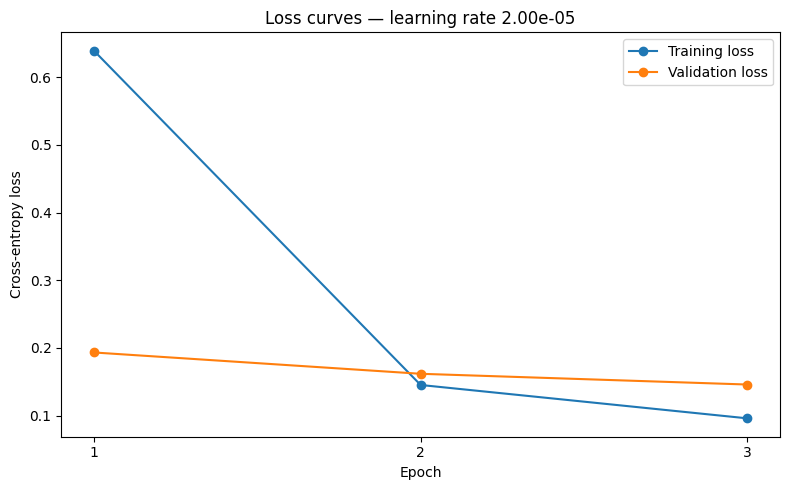

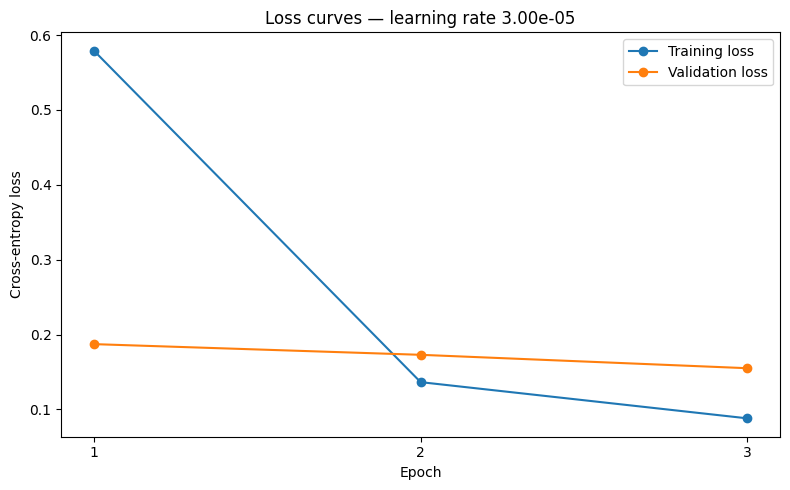

In [51]:
# Plot training and validation loss to inspect convergence and possible overfitting.
# Combine runs into one table while retaining learning-rate and epoch identifiers.
combined_training_history = pd.concat(
    transformer_histories.values(),
    ignore_index=True,
)
display(format_experiment_table(combined_training_history))

# Generate a separate loss figure for each experiment to avoid visually conflating training dynamics.
for learning_rate, history in transformer_histories.items():
    learning_rate_tag = f"{learning_rate:.0e}".replace("+", "").replace("-", "m")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["epoch"], history["train_loss"], marker="o", label="Training loss")
    ax.plot(
        history["epoch"],
        history["validation_loss"],
        marker="o",
        label="Validation loss",
    )
    ax.set_title(f"Loss curves — learning rate {learning_rate:.2e}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_xticks(history["epoch"])
    ax.legend()
    fig.tight_layout()
    save_and_show_figure(fig, f"loss_curves_lr_{learning_rate_tag}")


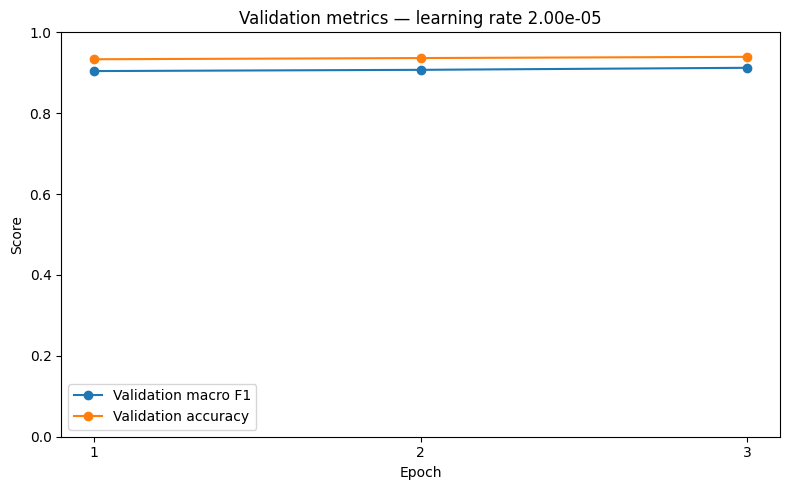

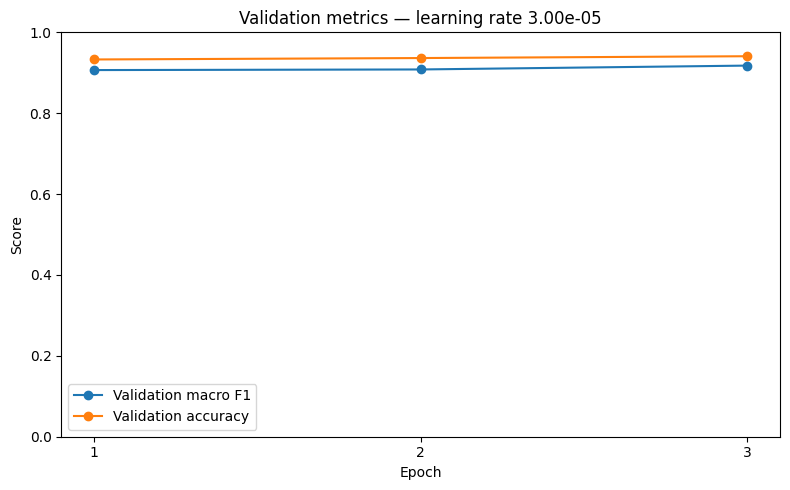

In [52]:
# Plot class-balanced validation performance alongside accuracy for each learning-rate run.
for learning_rate, history in transformer_histories.items():
    learning_rate_tag = f"{learning_rate:.0e}".replace("+", "").replace("-", "m")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(
        history["epoch"],
        # Macro F1 is shown because it is the checkpoint-selection metric under class imbalance.
        history["validation_f1_macro"],
        marker="o",
        label="Validation macro F1",
    )
    ax.plot(
        history["epoch"],
        # Accuracy is included for context but is not used to select the final checkpoint.
        history["validation_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    ax.set_title(f"Validation metrics — learning rate {learning_rate:.2e}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticks(history["epoch"])
    ax.legend()
    fig.tight_layout()
    save_and_show_figure(fig, f"validation_metrics_lr_{learning_rate_tag}")


## Phase 10 — Select both configurations, then evaluate the test set once

The transformer checkpoint is selected from validation macro F1. The baseline has already been fixed by training-only cross-validation. Only after both choices are complete are the two models evaluated on the protected test set in the same final phase.


In [53]:
# Select the transformer checkpoint using validation results only, before accessing the test set.
# The results table is already ordered by validation macro F1, so the first row is the selected run.
best_transformer_run = transformer_tuning_results.iloc[0]
best_checkpoint_dir = best_transformer_run["checkpoint_dir"]

print("Selected learning rate:", f"{best_transformer_run['learning_rate']:.2e}")
print("Selected epoch:", int(best_transformer_run["best_epoch"]))
print(
    "Best validation macro F1:",
    round(best_transformer_run["best_validation_f1_macro"], 4),
)
print("Checkpoint:", best_checkpoint_dir)

best_transformer = (
    AutoModelForSequenceClassification
    # Reload the saved best checkpoint rather than using the final epoch, which may not be optimal.
    .from_pretrained(best_checkpoint_dir)
    .to(DEVICE)
)


Selected learning rate: 3.00e-05
Selected epoch: 3
Best validation macro F1: 0.9177
Checkpoint: /content/emotion_assignment_outputs/distilbert_lr_3em05


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [54]:
# Perform the single final test evaluation after both model configurations have been fixed.
# This is the first and only test-set evaluation phase.
# Test labels become available only here, after baseline and transformer selection are complete.
final_test_labels = test_df["label"].to_numpy()

# Apply the frozen baseline once to the protected test texts.
baseline_test_predictions = best_baseline.predict(test_df["text"])
baseline_test_metrics = calculate_metrics(
    final_test_labels,
    baseline_test_predictions,
)
baseline_class_report = make_classification_report(
    final_test_labels,
    baseline_test_predictions,
)

# Apply the frozen best transformer checkpoint once using the same protected test split.
transformer_test_result = evaluate_model(best_transformer, test_loader)
transformer_test_metrics = transformer_test_result["metrics"]
transformer_test_predictions = transformer_test_result["predictions"]
transformer_test_probabilities = transformer_test_result["probabilities"]
transformer_test_labels = transformer_test_result["labels"]
transformer_class_report = make_classification_report(
    transformer_test_labels,
    transformer_test_predictions,
)

# Confirm transformer outputs preserve the same test-row order used by the baseline and source DataFrame.
assert np.array_equal(final_test_labels, transformer_test_labels)

# Place both models in one table so metrics are directly comparable under the identical holdout set.
final_test_metrics = pd.DataFrame(
    [
        {"model": "TF-IDF + Logistic Regression", **baseline_test_metrics},
        {"model": "Fine-tuned DistilBERT", **transformer_test_metrics},
    ]
)
display(final_test_metrics.round(4))
print("DistilBERT test loss:", round(transformer_test_result["loss"], 4))


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,TF-IDF + Logistic Regression,0.8825,0.8317,0.8720,0.8487,0.8842
1,Fine-tuned DistilBERT,0.9340,0.9010,0.8904,0.8950,0.9338


DistilBERT test loss: 0.1677


Baseline class-level report


,precision,recall,f1-score,support
sadness,0.9365,0.8881,0.9117,581.0000
joy,0.9238,0.8892,0.9062,695.0000
love,0.7200,0.9057,0.8022,159.0000
anger,0.8561,0.8873,0.8714,275.0000
fear,0.8791,0.8438,0.8610,224.0000
surprise,0.6750,0.8182,0.7397,66.0000
accuracy,0.8825,0.8825,0.8825,0.8825
macro avg,0.8317,0.8720,0.8487,2000.0000
weighted avg,0.8887,0.8825,0.8842,2000.0000


DistilBERT class-level report


,precision,recall,f1-score,support
sadness,0.9610,0.9759,0.9684,581.000
joy,0.9565,0.9482,0.9523,695.000
love,0.8282,0.8491,0.8385,159.000
anger,0.9470,0.9091,0.9276,275.000
fear,0.8856,0.9330,0.9087,224.000
surprise,0.8276,0.7273,0.7742,66.000
accuracy,0.9340,0.9340,0.9340,0.934
macro avg,0.9010,0.8904,0.8950,2000.000
weighted avg,0.9341,0.9340,0.9338,2000.000


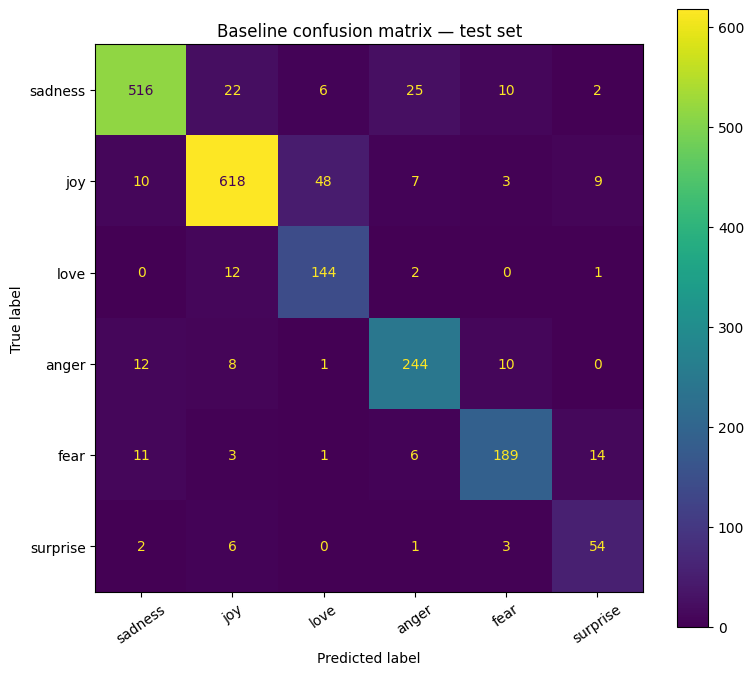

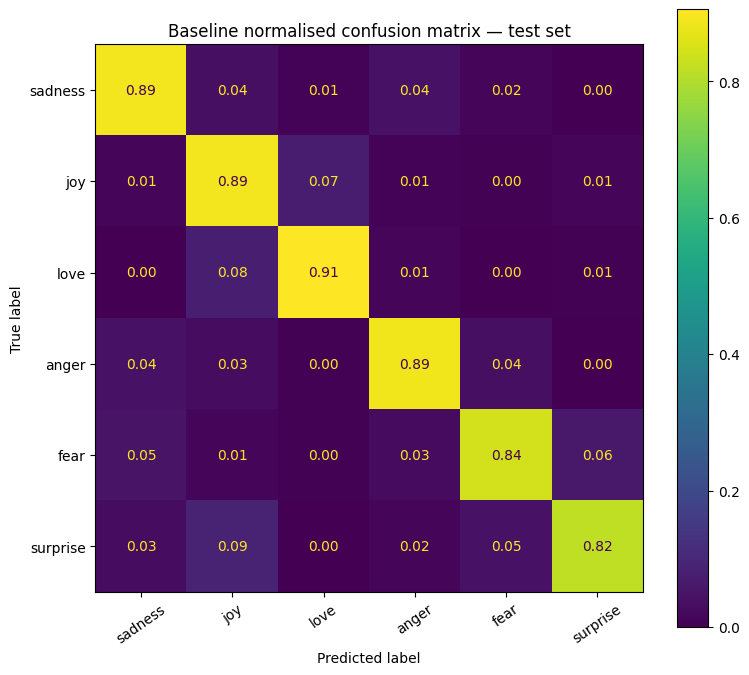

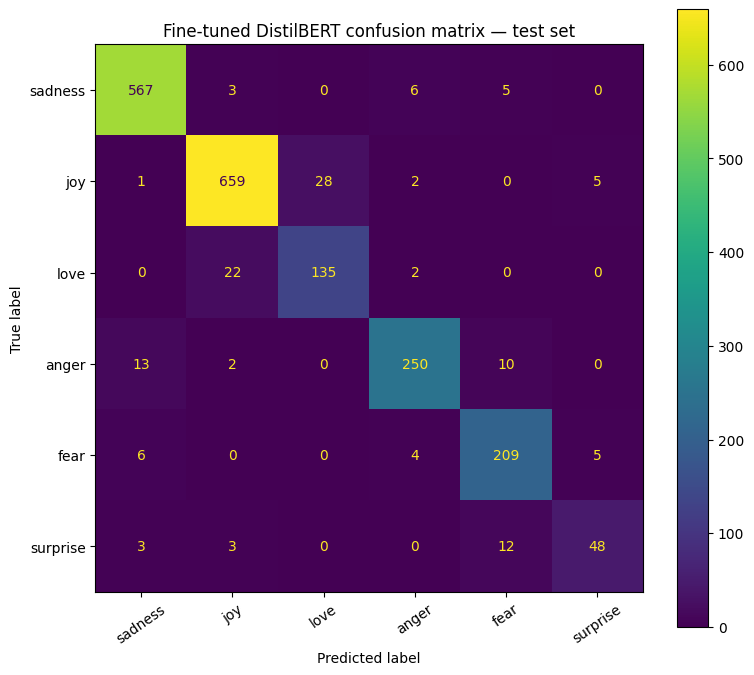

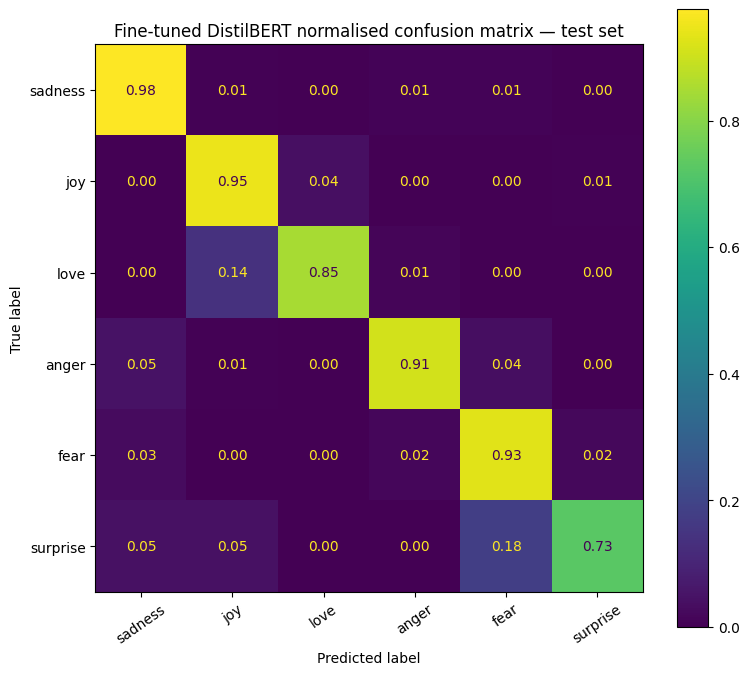

In [55]:
# Report class-level behaviour with raw and row-normalised confusion matrices.
print("Baseline class-level report")
display(baseline_class_report.round(4))

print("DistilBERT class-level report")
display(transformer_class_report.round(4))

# Raw counts reveal error volume; the following normalised matrices reveal per-class error rates.
plot_confusion(
    final_test_labels,
    baseline_test_predictions,
    title="Baseline confusion matrix — test set",
    file_stem="baseline_confusion_matrix_test",
)
plot_confusion(
    final_test_labels,
    baseline_test_predictions,
    title="Baseline normalised confusion matrix — test set",
    file_stem="baseline_confusion_matrix_normalised_test",
    normalize="true",
)
plot_confusion(
    transformer_test_labels,
    transformer_test_predictions,
    title="Fine-tuned DistilBERT confusion matrix — test set",
    file_stem="distilbert_confusion_matrix_test",
)
plot_confusion(
    transformer_test_labels,
    transformer_test_predictions,
    title="Fine-tuned DistilBERT normalised confusion matrix — test set",
    file_stem="distilbert_confusion_matrix_normalised_test",
    normalize="true",
)


## Phase 11 — Final model comparison

The table and report-ready figure directly compare the baseline and the fine-tuned BERT-style model using all required metrics.


In [56]:
# Keep a standalone copy of final metrics for direct reporting and later export.
# Copy the table so later plotting and export do not mutate the original final-evaluation object.
model_comparison = final_test_metrics.copy()
display(model_comparison.round(4))


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,TF-IDF + Logistic Regression,0.8825,0.8317,0.8720,0.8487,0.8842
1,Fine-tuned DistilBERT,0.9340,0.9010,0.8904,0.8950,0.9338


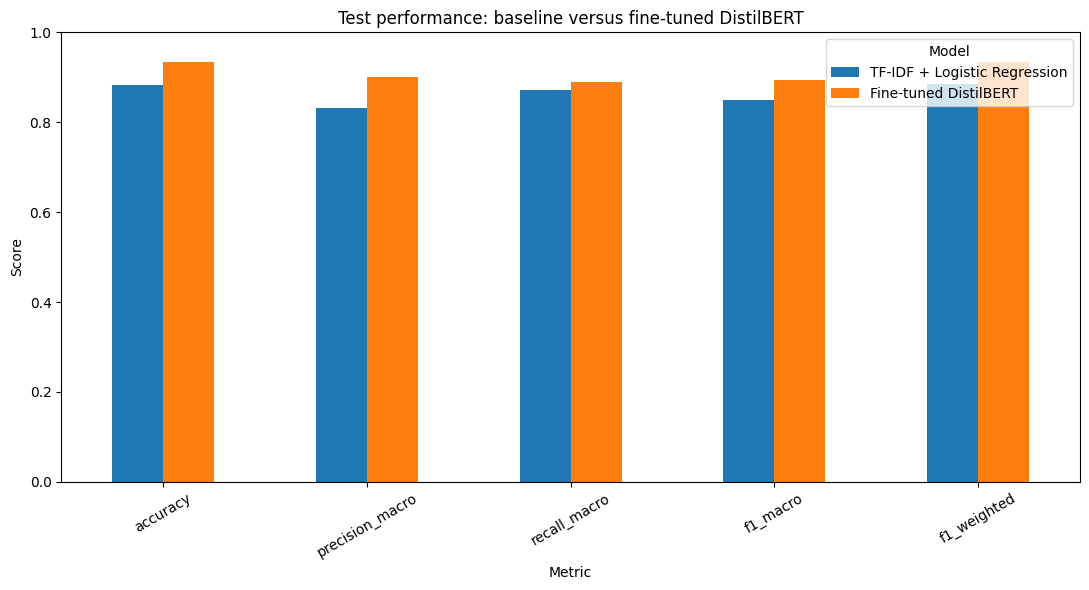

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
DistilBERT minus baseline,0.0515,0.0692,0.0184,0.0463,0.0496


In [57]:
# Compare aggregate test metrics and quantify the transformer's improvement over the baseline.
# Include both class-balanced and frequency-weighted metrics for a complete comparison.
metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
]

# Transpose the table so each metric becomes a grouped bar category.
comparison_plot_data = (
    model_comparison.set_index("model")[metric_columns].transpose()
)

fig, ax = plt.subplots(figsize=(11, 6))
comparison_plot_data.plot(kind="bar", ax=ax)
ax.set_title("Test performance: baseline versus fine-tuned DistilBERT")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Model")
fig.tight_layout()
save_and_show_figure(fig, "final_model_comparison")

# Positive values indicate the fine-tuned transformer outperformed the baseline on the same test cases.
metric_improvements = {
    metric: transformer_test_metrics[metric] - baseline_test_metrics[metric]
    for metric in metric_columns
}
metric_improvement_table = pd.DataFrame(
    [metric_improvements],
    index=["DistilBERT minus baseline"],
)
display(metric_improvement_table.round(4))


## Phase 12 — Class-level, confidence and error analysis

High-confidence mistakes, class-level F1 values and frequent confusion pairs are inspected so the conclusions critically interpret model weaknesses rather than merely list aggregate scores.


In [58]:
# Rank incorrect transformer predictions by confidence to expose confident failure cases.
# Use the largest softmax probability as the model's confidence in its chosen class.
prediction_confidence = transformer_test_probabilities.max(axis=1)

# Start from a copy of the official test rows so text, labels, predictions, and confidence stay aligned.
error_analysis = test_df[["text", "label"]].copy()
error_analysis["true_label"] = error_analysis["label"].map(ID2LABEL)
error_analysis["predicted_label_id"] = transformer_test_predictions
error_analysis["predicted_label"] = error_analysis[
    "predicted_label_id"
].map(ID2LABEL)
error_analysis["confidence"] = prediction_confidence
error_analysis["correct"] = (
    error_analysis["label"] == error_analysis["predicted_label_id"]
)

# Sort errors from most to least confident to prioritise the most concerning mistakes.
misclassified_examples = (
    error_analysis.loc[~error_analysis["correct"]]
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

print("Number of DistilBERT test errors:", len(misclassified_examples))
display(
    misclassified_examples[
        ["text", "true_label", "predicted_label", "confidence"]
    ].head(20)
)


Number of DistilBERT test errors: 132


,text,true_label,predicted_label,confidence
0,whenever i put myself in others shoes and try ...,anger,joy,0.999459
1,i walked to school he felt the bounce in his s...,love,joy,0.999321
2,i feel inside cause life is like a game someti...,fear,sadness,0.999125
3,i really dont like quinn because i feel like s...,anger,sadness,0.996660
4,i feel unprotected a class post count link hre...,sadness,fear,0.996426
5,i don t feel betrayed coz the backstabber had ...,surprise,sadness,0.994891
6,ive come to feel about a supporting character ...,joy,love,0.994430
7,i have reported feeling marginalized intimidat...,fear,sadness,0.992103
8,i feel betrayed and angry and sad at the same ...,anger,sadness,0.990895
9,i cannot even begin to express in words the de...,surprise,sadness,0.990646


In [59]:
# Identify common directed confusions and compare F1 for each emotion class.
# Direction matters: sadness→fear is counted separately from fear→sadness.
confusion_pairs = (
    misclassified_examples
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="error_count")
    .sort_values("error_count", ascending=False)
    .reset_index(drop=True)
)
display(confusion_pairs.head(15))

# Extract identical class-level columns from both reports for a fair side-by-side comparison.
baseline_per_class = baseline_class_report.loc[
    LABEL_NAMES, ["precision", "recall", "f1-score", "support"]
].copy()
transformer_per_class = transformer_class_report.loc[
    LABEL_NAMES, ["precision", "recall", "f1-score", "support"]
].copy()

per_class_comparison = pd.DataFrame(
    {
        "support": transformer_per_class["support"],
        "baseline_f1": baseline_per_class["f1-score"],
        "distilbert_f1": transformer_per_class["f1-score"],
    }
)
# Per-class gains reveal whether overall improvement extends to minority emotions.
per_class_comparison["f1_improvement"] = (
    per_class_comparison["distilbert_f1"]
    - per_class_comparison["baseline_f1"]
)
display(per_class_comparison.round(4))


,true_label,predicted_label,error_count
0,joy,love,28
1,love,joy,22
2,anger,sadness,13
3,surprise,fear,12
4,anger,fear,10
5,fear,sadness,6
6,sadness,anger,6
7,sadness,fear,5
8,joy,surprise,5
9,fear,surprise,5


,support,baseline_f1,distilbert_f1,f1_improvement
sadness,581.0,0.9117,0.9684,0.0567
joy,695.0,0.9062,0.9523,0.0462
love,159.0,0.8022,0.8385,0.0363
anger,275.0,0.8714,0.9276,0.0562
fear,224.0,0.8610,0.9087,0.0476
surprise,66.0,0.7397,0.7742,0.0345


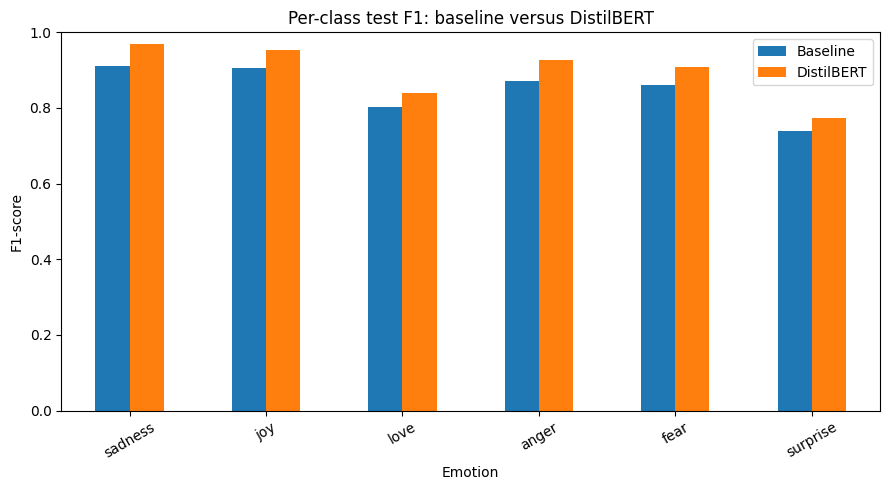

In [60]:
# Visualise per-class F1 so minority-class behaviour is not hidden by overall accuracy.
fig, ax = plt.subplots(figsize=(9, 5))
# Plot only F1 values here because support and improvement are available in the accompanying table.
per_class_comparison[["baseline_f1", "distilbert_f1"]].plot(
    kind="bar",
    ax=ax,
)
ax.set_title("Per-class test F1: baseline versus DistilBERT")
ax.set_xlabel("Emotion")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend(["Baseline", "DistilBERT"])
fig.tight_layout()
save_and_show_figure(fig, "per_class_f1_comparison")


### Automated interpretation for the report

The following cell converts the final outputs into concise, data-driven observations. The wording is generated from the new run, so it remains accurate when the corrected split handling changes the numerical results.


In [61]:
# Convert final numerical results into reproducible report-ready interpretation statements.
# Quantify generalisation change between the selected validation checkpoint and unseen test data.
validation_to_test_f1_gap = (
    float(best_transformer_run["best_validation_f1_macro"])
    - transformer_test_metrics["f1_macro"]
)
# A large accuracy-minus-macro-F1 gap can indicate weaker performance on less frequent classes.
accuracy_macro_f1_gap = (
    transformer_test_metrics["accuracy"]
    - transformer_test_metrics["f1_macro"]
)
smallest_class = per_class_comparison["support"].idxmin()
weakest_transformer_class = per_class_comparison["distilbert_f1"].idxmin()
smallest_class_gain = per_class_comparison["f1_improvement"].idxmin()
# Count confident mistakes as evidence for discussing probability calibration limitations.
high_confidence_error_count = int(
    (misclassified_examples["confidence"] >= 0.90).sum()
)

# Handle a theoretical perfect-classification case without indexing an empty table.
if confusion_pairs.empty:
    top_confusion_text = "No test-set misclassification pair was observed."
else:
    top_confusion = confusion_pairs.iloc[0]
    top_confusion_text = (
        f"The most frequent directed confusion was "
        f"{top_confusion['true_label']} → {top_confusion['predicted_label']} "
        f"({int(top_confusion['error_count'])} cases)."
    )

# Save the exact values behind narrative conclusions so the report remains traceable to notebook outputs.
interpretation_summary = pd.DataFrame(
    [
        {
            "distilbert_test_accuracy": transformer_test_metrics["accuracy"],
            "distilbert_test_macro_f1": transformer_test_metrics["f1_macro"],
            "baseline_test_macro_f1": baseline_test_metrics["f1_macro"],
            "macro_f1_improvement": metric_improvements["f1_macro"],
            "validation_to_test_macro_f1_gap": validation_to_test_f1_gap,
            "accuracy_minus_macro_f1": accuracy_macro_f1_gap,
            "smallest_test_class": smallest_class,
            "weakest_distilbert_class": weakest_transformer_class,
            "class_with_smallest_f1_gain": smallest_class_gain,
            "errors_with_confidence_at_least_0_90": high_confidence_error_count,
        }
    ]
)
display(interpretation_summary.round(4))

print(
    f"1. Fine-tuned DistilBERT achieved test accuracy "
    f"{transformer_test_metrics['accuracy']:.4f} and macro F1 "
    f"{transformer_test_metrics['f1_macro']:.4f}."
)
print(
    f"2. Its macro-F1 improvement over the baseline was "
    f"{metric_improvements['f1_macro']:.4f}."
)
print(
    f"3. The validation-to-test macro-F1 gap was "
    f"{validation_to_test_f1_gap:.4f}; this quantifies the observed "
    f"generalisation difference."
)
print(
    f"4. Accuracy exceeded macro F1 by {accuracy_macro_f1_gap:.4f}, "
    f"which is consistent with unequal class frequencies and weaker "
    f"performance on minority classes."
)
print(
    f"5. The smallest test class was '{smallest_class}', while the "
    f"lowest DistilBERT class F1 occurred for '{weakest_transformer_class}'."
)
print(f"6. {top_confusion_text}")
print(
    f"7. {high_confidence_error_count} incorrect predictions had confidence "
    f"of at least 0.90, indicating that probability calibration is a "
    f"reasonable future improvement."
)


,distilbert_test_accuracy,distilbert_test_macro_f1,baseline_test_macro_f1,macro_f1_improvement,validation_to_test_macro_f1_gap,accuracy_minus_macro_f1,smallest_test_class,weakest_distilbert_class,class_with_smallest_f1_gain,errors_with_confidence_at_least_0_90
0,0.934,0.895,0.8487,0.0463,0.0228,0.039,surprise,surprise,surprise,40


1. Fine-tuned DistilBERT achieved test accuracy 0.9340 and macro F1 0.8950.
2. Its macro-F1 improvement over the baseline was 0.0463.
3. The validation-to-test macro-F1 gap was 0.0228; this quantifies the observed generalisation difference.
4. Accuracy exceeded macro F1 by 0.0390, which is consistent with unequal class frequencies and weaker performance on minority classes.
5. The smallest test class was 'surprise', while the lowest DistilBERT class F1 occurred for 'surprise'.
6. The most frequent directed confusion was joy → love (28 cases).
7. 40 incorrect predictions had confidence of at least 0.90, indicating that probability calibration is a reasonable future improvement.


### Limitations to address in the three-page report

- Results are based on one English emotion dataset and may not generalise to other domains or languages.
- Only one BERT-style architecture and two learning rates are compared because of the assignment compute budget.
- The experiment uses one fixed seed; repeated-seed training would provide a stronger estimate of optimisation variability.
- Minority classes have fewer examples, so accuracy can conceal weaker class-balanced performance; macro F1 is therefore the primary metric.
- Some errors may reflect short, ambiguous or inconsistently annotated text rather than model failure alone.
- High-confidence errors motivate future calibration analysis, such as temperature scaling.


## Phase 13 — Paired bootstrap uncertainty analysis

This optional research-strength analysis estimates a 95% confidence interval for the macro-F1 improvement. Both models are evaluated on the same resampled test observations.


In [62]:
# Estimate uncertainty in the paired macro-F1 improvement using the same resampled test cases for both models.
def paired_bootstrap_f1_difference(
    y_true,
    prediction_a,
    prediction_b,
    iterations: int = 1_000,
    seed: int = 42,
) -> dict:
    # Use a local seeded generator so bootstrap sampling is reproducible without altering global randomness.
    rng = np.random.default_rng(seed)
    sample_size = len(y_true)
    differences = []

    for _ in range(iterations):
        # Resample observation indices with replacement and apply the same indices to both models.
        indices = rng.integers(0, sample_size, size=sample_size)
        sampled_true = y_true[indices]

        score_a = f1_score(
            sampled_true,
            prediction_a[indices],
            average="macro",
            zero_division=0,
        )
        score_b = f1_score(
            sampled_true,
            prediction_b[indices],
            average="macro",
            zero_division=0,
        )
        # Paired differences preserve within-example dependence and isolate relative model performance.
        differences.append(score_a - score_b)

    differences = np.asarray(differences)

    return {
        "observed_macro_f1_difference": (
            f1_score(
                y_true,
                prediction_a,
                average="macro",
                zero_division=0,
            )
            - f1_score(
                y_true,
                prediction_b,
                average="macro",
                zero_division=0,
            )
        ),
        "bootstrap_mean_difference": differences.mean(),
        # Percentile bounds summarise the central 95% of bootstrap improvement estimates.
        "ci_95_lower": np.quantile(differences, 0.025),
        "ci_95_upper": np.quantile(differences, 0.975),
        # This proportion estimates how consistently the transformer improvement remains positive across resamples.
        "probability_difference_above_zero": (differences > 0).mean(),
    }


bootstrap_result = paired_bootstrap_f1_difference(
    y_true=final_test_labels,
    prediction_a=np.asarray(transformer_test_predictions),
    prediction_b=np.asarray(baseline_test_predictions),
    iterations=CFG.bootstrap_iterations,
    seed=CFG.seed,
)
display(
    pd.DataFrame(
        [bootstrap_result],
        index=["DistilBERT minus baseline"],
    ).round(4)
)


,observed_macro_f1_difference,bootstrap_mean_difference,ci_95_lower,ci_95_upper,probability_difference_above_zero
DistilBERT minus baseline,0.0463,0.0461,0.022,0.07,1.0


## Phase 14 — New-text inference demonstration

The examples below demonstrate application of the selected fine-tuned model. They are not part of validation or test evaluation.


In [63]:
# Provide an inference helper for genuinely new text without mixing demonstration examples into evaluation.
# Inference does not require gradients, reducing memory use and preventing accidental parameter updates.
@torch.no_grad()
def predict_emotion(texts, model, tokenizer) -> pd.DataFrame:
    # Accept either one string or a list while keeping the downstream batching path consistent.
    if isinstance(texts, str):
        texts = [texts]

    encoded = tokenizer(
        texts,
        # Dynamic padding batches the supplied examples efficiently while truncation matches training preprocessing.
        padding=True,
        truncation=True,
        max_length=CFG.max_length,
        return_token_type_ids=False,
        return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

    # Evaluation mode disables dropout so repeated inference is deterministic.
    model.eval()
    probabilities = torch.softmax(model(**encoded).logits, dim=1)
    # Choose the highest-probability emotion while retaining its probability as an interpretable confidence score.
    predicted_ids = probabilities.argmax(dim=1)

    rows = []
    for text, predicted_id, probability_vector in zip(
        texts,
        predicted_ids.cpu().numpy(),
        probabilities.cpu().numpy(),
    ):
        rows.append(
            {
                "text": text,
                "predicted_emotion": ID2LABEL[int(predicted_id)],
                "confidence": float(probability_vector[int(predicted_id)]),
            }
        )
    return pd.DataFrame(rows)


# These examples demonstrate deployment only and are excluded from validation and test metrics.
demonstration_texts = [
    "I am delighted that the project was approved.",
    "I feel nervous about what might happen tomorrow.",
    "I cannot believe they treated me that way.",
    "I miss the people who used to support me.",
]
display(predict_emotion(demonstration_texts, best_transformer, tokenizer))


,text,predicted_emotion,confidence
0,I am delighted that the project was approved.,joy,0.999279
1,I feel nervous about what might happen tomorrow.,fear,0.998924
2,I cannot believe they treated me that way.,anger,0.965367
3,I miss the people who used to support me.,sadness,0.926097


## Phase 15 — Save reproducible artefacts

The selected baseline, transformer checkpoints, configuration, test predictions, report-ready tables, figures and exact environment requirements are saved and compressed into one archive.


In [64]:
# Save models, tables, predictions, metadata, figures, and package versions as reproducible submission artefacts.
# Persist the complete TF-IDF pipeline so vectorisation and classification can be reproduced together.
joblib.dump(
    best_baseline,
    OUTPUT_DIR / "tfidf_logistic_regression.joblib",
)

# Export audit and cleaning tables as evidence of data-quality and leakage controls.
initial_audit.to_csv(OUTPUT_DIR / "initial_data_audit.csv", index=False)
overlap_audit.to_csv(OUTPUT_DIR / "split_overlap_audit.csv", index=False)
cleaning_summary.to_csv(OUTPUT_DIR / "cleaning_summary.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)
class_distribution.to_csv(OUTPUT_DIR / "class_distribution.csv", index=False)
architecture_summary.to_csv(OUTPUT_DIR / "architecture_summary.csv", index=False)
baseline_cv_results.to_csv(OUTPUT_DIR / "baseline_cv_results.csv", index=False)
pd.DataFrame([baseline_validation_metrics]).to_csv(
    OUTPUT_DIR / "baseline_validation_metrics.csv",
    index=False,
)
baseline_class_report.to_csv(
    OUTPUT_DIR / "baseline_classification_report.csv"
)
# Preserve epoch-level histories and model-selection tables for report verification.
combined_training_history.to_csv(
    OUTPUT_DIR / "transformer_training_history.csv",
    index=False,
)
transformer_tuning_results.to_csv(
    OUTPUT_DIR / "transformer_tuning_results.csv",
    index=False,
)
transformer_class_report.to_csv(
    OUTPUT_DIR / "transformer_classification_report.csv"
)
model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
metric_improvement_table.to_csv(
    OUTPUT_DIR / "metric_improvements.csv",
    index=True,
)
per_class_comparison.to_csv(OUTPUT_DIR / "per_class_comparison.csv")
interpretation_summary.to_csv(
    OUTPUT_DIR / "interpretation_summary.csv",
    index=False,
)
# Save error-analysis evidence rather than relying only on notebook display output.
misclassified_examples.to_csv(
    OUTPUT_DIR / "distilbert_error_analysis.csv",
    index=False,
)
confusion_pairs.to_csv(
    OUTPUT_DIR / "distilbert_confusion_pairs.csv",
    index=False,
)
pd.DataFrame([bootstrap_result]).to_csv(
    OUTPUT_DIR / "bootstrap_f1_difference.csv",
    index=False,
)

# Keep row-level predictions from both frozen models aligned with the original protected test examples.
prediction_output = test_df[["text", "label"]].copy()
prediction_output["true_label"] = prediction_output["label"].map(ID2LABEL)
prediction_output["baseline_prediction_id"] = baseline_test_predictions
prediction_output["baseline_prediction"] = prediction_output[
    "baseline_prediction_id"
].map(ID2LABEL)
prediction_output["distilbert_prediction_id"] = transformer_test_predictions
prediction_output["distilbert_prediction"] = prediction_output[
    "distilbert_prediction_id"
].map(ID2LABEL)
prediction_output["distilbert_confidence"] = prediction_confidence
prediction_output.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)

# Record exact core package versions so the successful software environment can be recreated.
requirements = "\n".join(
    [
        "transformers==5.13.1",
        "datasets==5.0.0",
        "kagglehub==1.0.2",
        "scikit-learn==1.6.1",
        f"torch=={torch.__version__}",
        f"numpy=={np.__version__}",
        f"pandas=={pd.__version__}",
        f"joblib=={joblib.__version__}",
    ]
) + "\n"
(OUTPUT_DIR / "requirements.txt").write_text(requirements, encoding="utf-8")

# Store configuration, dataset fingerprints, selected checkpoints, and the one-time-test protocol in machine-readable form.
run_metadata = {
    "config": asdict(CFG),
    "device": str(DEVICE),
    "label_names": LABEL_NAMES,
    "test_evaluated_only_in_final_phase": True,
    "test_labels_used_for_cleaning_or_selection": False,
    "official_test_rows_after_independent_validity_check": len(test_df),
    "kaggle_dataset_handle": CFG.kaggle_dataset_handle,
    "kaggle_dataset_directory": str(kaggle_dataset_directory),
    "kaggle_dataset_file_hashes": KAGGLE_FILE_HASHES,
    "best_baseline_parameters": baseline_search.best_params_,
    "best_transformer_checkpoint": best_checkpoint_dir,
    "package_versions": {
        "python": sys.version,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "datasets": datasets.__version__,
        "kagglehub": getattr(kagglehub, "__version__", "version unavailable"),
        "joblib": joblib.__version__,
    },
}

# Serialise metadata separately from model files for transparent inspection without loading a checkpoint.
with open(
    OUTPUT_DIR / "run_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(run_metadata, file, indent=2, default=str)

# Bundle the complete output directory into one submission-friendly archive.
archive_path = shutil.make_archive(
    base_name=str(OUTPUT_DIR),
    format="zip",
    root_dir=str(OUTPUT_DIR),
)

print("Output folder:", OUTPUT_DIR.resolve())
print("Archive:", Path(archive_path).resolve())
# Print a final manifest so the student can verify every expected artefact was produced.
for saved_file in sorted(OUTPUT_DIR.rglob("*")):
    if saved_file.is_file():
        print("-", saved_file.relative_to(OUTPUT_DIR))


Output folder: /content/emotion_assignment_outputs
Archive: /content/emotion_assignment_outputs.zip
- architecture_summary.csv
- baseline_classification_report.csv
- baseline_cv_results.csv
- baseline_validation_metrics.csv
- bootstrap_f1_difference.csv
- class_distribution.csv
- cleaning_summary.csv
- distilbert_confusion_pairs.csv
- distilbert_error_analysis.csv
- distilbert_lr_2em05/config.json
- distilbert_lr_2em05/model.safetensors
- distilbert_lr_2em05/tokenizer.json
- distilbert_lr_2em05/tokenizer_config.json
- distilbert_lr_3em05/config.json
- distilbert_lr_3em05/model.safetensors
- distilbert_lr_3em05/tokenizer.json
- distilbert_lr_3em05/tokenizer_config.json
- figures/baseline_confusion_matrix_normalised_test.pdf
- figures/baseline_confusion_matrix_normalised_test.png
- figures/baseline_confusion_matrix_test.pdf
- figures/baseline_confusion_matrix_test.png
- figures/distilbert_architecture_pipeline.pdf
- figures/distilbert_architecture_pipeline.png
- figures/distilbert_confus